In [1]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pandas as pd

from architecture.config import load_config

In [2]:
config = load_config("configs/default.yaml")
log_dir = Path(config["paths"]["log"])

df = pd.read_csv(log_dir / "log.csv")

checkpoint_epochs = range(10, df["epoch"].iloc[-1] + 1, 10)
image_paths = [log_dir / f"epoch_{epoch}.png" for epoch in checkpoint_epochs]

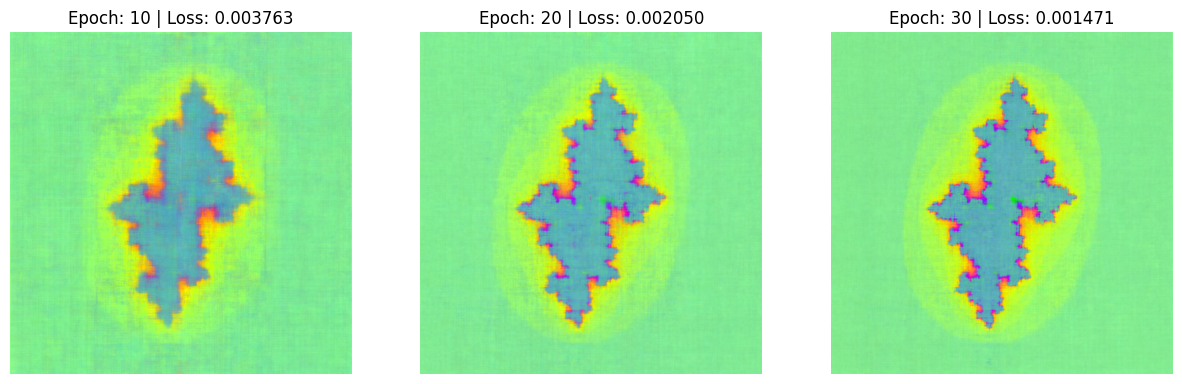

In [3]:
fig, axes = plt.subplots(1, len(image_paths), figsize=(len(image_paths) * 5, 5))

for ax, epoch, image_path in zip(axes, checkpoint_epochs, image_paths):
    loss = df.loc[df["epoch"] == epoch, "loss"].iloc[0]
    ax.imshow(Image.open(image_path))
    ax.axis("off")
    ax.set_title(f"Epoch: {epoch} | Loss: {loss:.6f}")